<a href="https://colab.research.google.com/github/BahruzHuseynov/Portfolio/blob/main/2_DND_Assignment_2_23_24_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 - Image Captioning

This notebook contains the required task for the second assignment of the Deep Network Development course. Read the task description and fill in the empty code cells. Each section represents an implementation stage of image captioning : -from loading and inspecting the dataset; -to implementing, training and evaluating an Encoder-Decoder + Attention based architecture. The sections are there to guide you but you do not have to follow them strictly.

Copy this notebook to your drive (File -> Save a copy in Drive), edit it, and upload the final .ipynb file to [Canvas](https://canvas.elte.hu). If you are using this in Google Colab notebook, save it as .ipynb and upload it, or share the public link. If you have your own machine with Jupyter installed, you can work there as well, as long as you save and upload the .ipynb file.


## General Rules
Please check all the requirements listed on Canvas, but here are some general rules:
- From the provided Flickr8k dataset, split it into train, val and test sets;
- Use the train set to train an Image Captioning model, the val set for validation of the model and hyper-parameters, and the test set to evaluate the final trained model;
- For this assignment, we will give importance to the performance of your model, meaning that, we will evaluate if your model is overfitted or underfitted. For that, please include visualizations (print and plot) loss values for the split sets, as well as the metric results;
- For the metric, while we do not require high performance, we still expect better than random guessing results;
- For the comparison, you are free to choose any pre-trained model;
- Copying others' code will make you fail the assignment automatically, resulting in a 0;
- Not submitting anything results in a 0;
- Submitting something, as long as it is not an empty notebook, might result in a 1;
- **Deadline is May 15th Wednesday 11:59 PM** (strict, no late submission);
- Feel free to add more code cells as needed. But don't put code into external Python files;
- Please add your name, Neptun ID, and task details below.

**Name:**  
**Neptun ID:**

## Task description

Your task is to train your own custom image captioning model and compare its performance with an existing (pre-trained) model. For that, first you need to load the provided Flickr8k dataset, split into train, val and test sets. Then, create your own architecture, which should follow an Encoder-Decoder + Attention sturcture. You can use pre-trained backbones (i.e. ResNet) for the encoder, but they have to be fine-tuned. We expect you to use an Attention layer, in order to visualize how the network learned (see more details on section 2 of the notebook).
There is no expected high performance, but **your metrics should show results better than random guessing and your loss has to decrease throughout the epochs. Please use BLEU score as the metric**. We expect you to show visualizations (prints and plots) of the metrics, losses, and predictions. Use techniques to avoid overfitting such as Early stopping, and more, and save the best model while training your architecture.

**In order to get your grade for the assignment, you must defend it by answering questions during the designated practice time.**

## Guidelines
Please carefully read each cell of the notebook, as they contain guidelines to help you complete the assignments. While you don't have to follow them strictly, we believe that they provide enough help.

# 0. Necessary Imports
Import all the necessary packages for this assignment. **ONLY PYTORCH MODELS ARE ACCEPTED!**

In [142]:
import os
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence
from nltk.translate.bleu_score import corpus_bleu
from tqdm import tqdm

from torchvision import models, transforms

from torch.utils.data import Dataset, DataLoader, random_split

# 1. DATASET
For this assignment you will be using the [Flickr8k](https://www.kaggle.com/datasets/adityajn105/flickr8k) dataset, which contains captions/descriptions of different images.

### 1.1. Download dataset
The best way to download this dataset is through Kaggle.
First create a token, download it and upload it here. Follow these steps: https://www.kaggle.com/discussions/general/74235

In [2]:
!pip install -q kaggle

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hbahruz","key":"44ffa2fb7937a90950ec027d3565ed14"}'}

In [4]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d adityajn105/flickr8k

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:54<00:00, 20.8MB/s]
100% 1.04G/1.04G [00:54<00:00, 20.4MB/s]


In [6]:
!unzip flickr8k.zip

Streaming output truncated to the last 5000 lines.
  inflating: Images/2844846111_8c1cbfc75d.jpg  
  inflating: Images/2844963839_ff09cdb81f.jpg  
  inflating: Images/2845246160_d0d1bbd6f0.jpg  
  inflating: Images/2845691057_d4ab89d889.jpg  
  inflating: Images/2845845721_d0bc113ff7.jpg  
  inflating: Images/2846037553_1a1de50709.jpg  
  inflating: Images/2846785268_904c5fcf9f.jpg  
  inflating: Images/2846843520_b0e6211478.jpg  
  inflating: Images/2847514745_9a35493023.jpg  
  inflating: Images/2847615962_c330bded6e.jpg  
  inflating: Images/2847859796_4d9cb0d31f.jpg  
  inflating: Images/2848266893_9693c66275.jpg  
  inflating: Images/2848571082_26454cb981.jpg  
  inflating: Images/2848895544_6d06210e9d.jpg  
  inflating: Images/2848977044_446a31d86e.jpg  
  inflating: Images/2849194983_2968c72832.jpg  
  inflating: Images/2850719435_221f15e951.jpg  
  inflating: Images/2851198725_37b6027625.jpg  
  inflating: Images/2851304910_b5721199bc.jpg  
  inflating: Images/2851931813_eaf8ed

### 1.2. Load dataset
In order to load the dataset, you need to create a pytorch Dataset class.
The class should return images and captions. Remember that the captions should be returned as tokens. Do not forget to include the SOS:start of sentence, EOS:end of sentence and UNK:unknown tokens. You may want to build a vocabulary class in order to save all the words in your dataset, because your model can only predict words in your vocabulary. You do not have to save every word in your vocabulary, it is common practice to save only those words that appear multiple times in your whole dataset. For example, save only words that appear at least 5 times in your whole dataset.

In [116]:
class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, transform=None, num_samples = 5000, freq_threshold=5):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.captions = []

        with open(captions_file, 'r') as f:
            next(f)  # skip header
            for line in f:
                image_filename, caption = line.strip().split(',', 1)
                image_path = os.path.join(root_dir, image_filename)
                if os.path.exists(image_path):
                    self.image_paths.append(image_path)
                    self.captions.append(caption)

                num_samples -= 1
                if num_samples == 0:
                    break

        word_counts = Counter()
        for caption in self.captions:
            words = caption.lower().split()
            word_counts.update(words)

        self.max_caption_length = max(len(caption.split()) for caption in self.captions)

        # Filtering infrequent words out
        filtered = [word for word, count in word_counts.items() if count >= freq_threshold]
        self.vocab = ["<UNK>", "<SOS>", "<EOS>", "<PAD>"] + filtered

        self.vocab_size = len(self.vocab)
        self.word2idx = {word: idx for idx, word in enumerate(self.vocab)}
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}

    def caption_to_vector(self, caption):
        vector = [self.word2idx.get(word, self.word2idx["<UNK>"]) for word in caption.lower().split()]
        vector = [self.word2idx["<SOS>"]] + vector + [self.word2idx["<EOS>"]]

        # Right padding
        padded_vector = vector + [self.word2idx["<PAD>"]] * (self.max_caption_length - len(vector))
        return padded_vector

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert('RGB')

        if self.transform is not None:
            img = self.transform(img)

        caption = self.captions[idx]
        caption_vec = self.caption_to_vector(caption)
        return img, torch.tensor(caption_vec)

Example output from dataset class

In [117]:
dataset = FlickrDataset("Images", "captions.txt")

In [118]:
img, caps= dataset[0]
print(caps)
print([dataset.idx2word[int(cap)] for cap in caps])

tensor([ 1,  4,  5,  6,  4,  7,  8,  9, 10, 11,  4, 12, 13, 14,  6, 15,  0, 16,
        17,  2,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3])
['<SOS>', 'a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', '<UNK>', 'way', '.', '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']


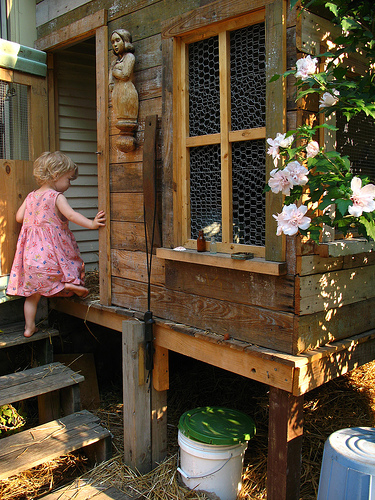

In [119]:
img

Split your dataset into train, val and test sets

In [120]:
# Applying transformation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = FlickrDataset("Images", "captions.txt", transform)

In [121]:
train_size = int(len(dataset) * 0.8)
val_size = int(len(dataset) * 0.1)
test_size = len(dataset) - train_size - val_size
len_dataset = len(dataset)
print(len_dataset)
print(train_size, val_size, test_size)

5000
4000 500 500


In [122]:
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

Create a dataloader, in order to load the examples in batches. Remember that, a batch has different examples, and each example (caption) may have different sizes. Therefore, consider padding techniques for the captions. For the image, use transforms in the previous step, to ensure same format and size.  

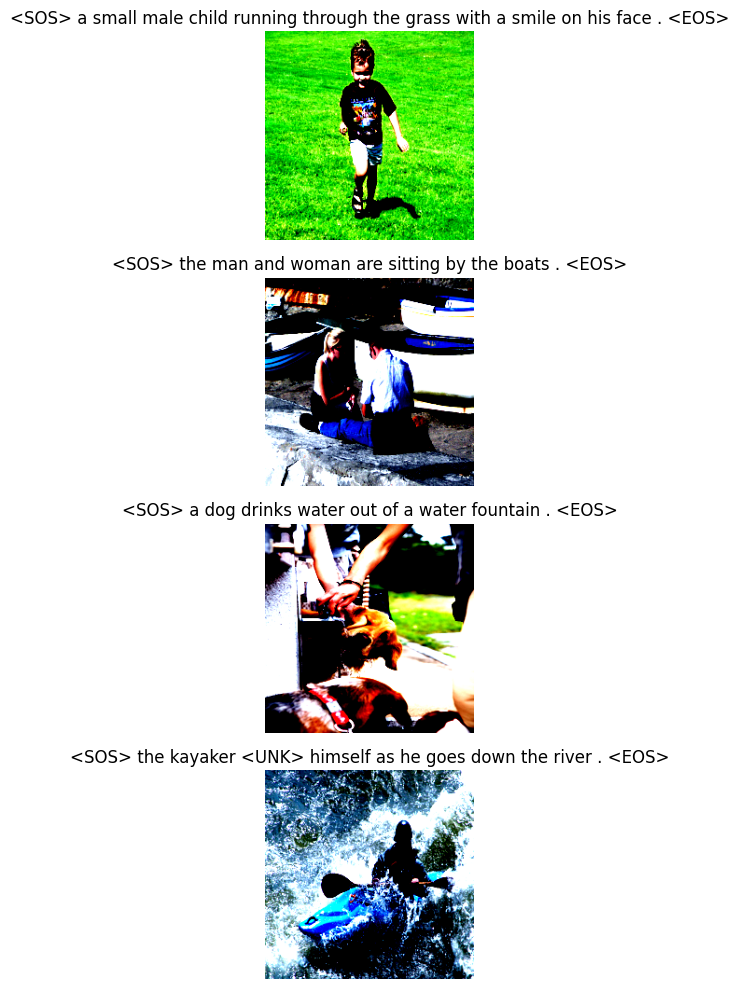

In [123]:
for batch_idx, (images, captions) in enumerate(train_loader):
    fig, axes = plt.subplots(4, 1, figsize=(10, 10))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        image = images[i].permute(1, 2, 0)
        ax.imshow(image)
        ax.axis('off')

        s = [dataset.idx2word[int(cap)] for cap in captions[i]]
        s = [i for i in s if i != "<PAD>"]
        ax.set_title(" ".join(s))

    plt.tight_layout()
    plt.show()

    break

#2. MODEL
For this assignment, you are required to create your own custom image captioning model and compare its performance with an existing pre-trained model.

In [124]:
#Make sure to use GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

### 2.1. Custom Image Captioning model

Create an Encoder-Attention-Decoder architecture with the following details:
- the encoder should process the images, thus you can create a Convolutional based architecture or use already pre-trained models like ResNet. However, you must fine-tune the pretrained model. The encoder is responisble for extracting image features;
- the attention layer should be between the encoder and decoder. It uses the image features from the encoder in order to provide context (attention scores) to the decoder hidden layers. For simplicity use Linear layers as the attention architecture;
- the decoder should be a sequence based model (i.e. LSTM) in order to process and generate captions.

Extra:
- Extra points (counting toward the final grade) will be given to any student who implements either a Vision-based Transformer architecture or a Transformer only decoder for the decoder part.

#### Reference
Here is an example of something similar to what we want to create:
<img src="https://drive.google.com/thumbnail?id=1wdddaLit7iEyCcVy5bS505NiYzL6c-4x&sz=w1000">


In [132]:
class Encoder(nn.Module):
    def __init__(self, embed_size):
        super(Encoder, self).__init__()
        resnet = models.resnet50(pretrained=True)

        for param in resnet.parameters():
            param.requires_grad = True  # Fine-tune all layers

        modules = list(resnet.children())[:-1]  # Remove last layer (fully connected)
        self.resnet = nn.Sequential(*modules)
        self.embed = nn.Linear(resnet.fc.in_features, embed_size)
        self.bn = nn.BatchNorm1d(embed_size, momentum=0.01)

    def forward(self, images):
        with torch.no_grad():
            features = self.resnet(images)
        features = features.reshape(features.size(0), -1)
        features = self.bn(self.embed(features))
        return features

In [133]:
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden)
        att = self.full_att(self.relu(att1 + att2.unsqueeze(1))).squeeze(2)
        alpha = self.softmax(att)
        attention_weighted_encoding = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return attention_weighted_encoding, alpha

In [237]:
class Decoder(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1, max_caption_length=20):
        super(Decoder, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size + embed_size, vocab_size)
        self.max_caption_length = max_caption_length

    def forward(self, features, captions):
        embeddings = self.embed(captions)

        # Expand input tensor to include sequence length dimension
        inputs = torch.cat((features.unsqueeze(1), embeddings), dim=1)
        print("Input shape to LSTM:", inputs.shape)

        hiddens, _ = self.lstm(inputs)
        print("Output shape from LSTM:", hiddens.shape)

        outputs = self.fc(hiddens)
        return outputs

    def sample(self, features, states=None):
        sampled_ids = []
        inputs = features.unsqueeze(1)
        for i in range(self.max_caption_length):
            hiddens, states = self.lstm(inputs, states)
            outputs = self.fc(torch.cat((hiddens, features.unsqueeze(1)), dim=2))
            _, predicted = outputs.max(2)
            sampled_ids.append(predicted)
            inputs = self.embed(predicted)
        sampled_ids = torch.stack(sampled_ids, 1)
        return sampled_ids


Combine the encoder - attention - decoder

In [238]:
class CaptioningModel(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim, num_layers=1, max_caption_length=20):
        super(CaptioningModel, self).__init__()
        self.encoder = Encoder(embed_size)
        self.decoder = Decoder(embed_size, hidden_size, vocab_size, num_layers, max_caption_length)
        self.attention = Attention(embed_size, hidden_size, attention_dim)

    def forward(self, images, captions):
        features = self.encoder(images)
        hiddens = None
        outputs = []
        for t in range(captions.size(1) - 1):
            hidden, hiddens = self.decoder.lstm(captions[:, t].unsqueeze(1), hiddens)
            context, alpha = self.attention(features, hidden.squeeze(0))
            # Ensure hidden has the same dimension as context
            hidden = hidden.squeeze(0)
            predicted = self.decoder.fc(torch.cat([hidden, context.unsqueeze(1)], dim=2))  # Adjust dim=2 for concatenation
            outputs.append(predicted)
        outputs = torch.stack(outputs, dim=1)
        return outputs

    def sample(self, images, states=None):
        features = self.encoder(images)
        sampled_ids = self.decoder.sample(features, states)
        return sampled_ids


### 2.2. Training custom model

In [239]:
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for images, captions in tqdm(train_loader):
        images = images.to(device)
        captions = captions.to(device)

        optimizer.zero_grad()

        outputs = model(images, captions)

        targets = pack_padded_sequence(captions[:, 1:], [len(caption)-1 for caption in captions], batch_first=True).data
        loss = criterion(outputs.reshape(-1, outputs.size(2)), targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

def validate(model, val_loader, criterion, device, vocab):
    model.eval()
    total_loss = 0.0
    references = []
    hypotheses = []
    with torch.no_grad():
        for images, captions in tqdm(val_loader):
            images = images.to(device)
            captions = captions.to(device)

            outputs = model(images, captions)

            targets = pack_padded_sequence(captions[:, 1:], [len(caption)-1 for caption in captions], batch_first=True).data
            loss = criterion(outputs.reshape(-1, outputs.size(2)), targets)

            total_loss += loss.item()

            # Generate captions
            sampled_ids = model.sample(images)
            sampled_ids = sampled_ids.cpu().numpy()

            # Convert indices to words
            captions = captions.cpu().numpy()
            for caption, sampled_id in zip(captions, sampled_ids):
                reference = [vocab.idx2word[word_idx] for word_idx in caption[1:] if word_idx != vocab.word2idx['<PAD>']]
                hypothesis = [vocab.idx2word[word_idx] for word_idx in sampled_id if word_idx != vocab.word2idx['<PAD>']]

                references.append([reference])
                hypotheses.append(hypothesis)

    bleu_score = corpus_bleu(references, hypotheses)
    return total_loss / len(val_loader), bleu_score

In [240]:
embed_size = 256
hidden_size = 512
attention_dim = 512
num_layers = 1
max_caption_length = 20
batch_size = 32
learning_rate = 0.001

model = CaptioningModel(embed_size, hidden_size, dataset.vocab_size, attention_dim, num_layers, max_caption_length).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=dataset.word2idx['<PAD>'])
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [241]:
train_losses = []
val_losses = []
val_bleu_scores = []
num_epochs = 8

for epoch in range(num_epochs):
    # Training
    train_loss = train(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)

    # Validation
    val_loss, val_bleu_score = validate(model, val_loader, criterion, device, train_dataset)
    val_losses.append(val_loss)
    val_bleu_scores.append(val_bleu_score)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val BLEU Score: {val_bleu_score:.4f}')

  0%|          | 0/125 [00:00<?, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x1 and 256x2048)

In [250]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import os
from PIL import Image
from collections import Counter
from torch.utils.data import Dataset
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define Encoder
class Encoder(nn.Module):
    def __init__(self, embed_size):
        super(Encoder, self).__init__()
        resnet = models.resnet50(pretrained=True)
        modules = list(resnet.children())[:-1]  # Remove last layer
        self.resnet = nn.Sequential(*modules)
        self.fc = nn.Linear(resnet.fc.in_features, embed_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, images):
        with torch.no_grad():
            features = self.resnet(images)
        features = features.reshape(features.size(0), -1)
        features = self.dropout(features)
        features = self.fc(features)
        return features

# Define Attention
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden)

        # Ensure dimensions are compatible for matrix multiplication
        if att2.dim() == 2:
            att2 = att2.unsqueeze(1)

        att = self.full_att(self.relu(att1 + att2)).squeeze(2)
        alpha = self.softmax(att)
        attention_weighted_encoding = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return attention_weighted_encoding, alpha


# Define Decoder
class Decoder(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim, dropout=0.5):
        super(Decoder, self).__init__()
        self.attention_dim = attention_dim
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(hidden_size, hidden_size, attention_dim)
        self.lstm = nn.LSTM(embed_size + hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, encoder_out, captions, lengths):
        embeddings = self.embed(captions)
        embeddings = self.dropout(embeddings)
        h, c = torch.zeros_like(encoder_out).to(device), torch.zeros_like(encoder_out).to(device)

        decode_lengths = [length - 1 for length in lengths]
        predictions = torch.zeros(len(captions), max(decode_lengths), self.fc.out_features).to(device)

        for t in range(max(decode_lengths)):
            batch_size_t = sum([l > t for l in decode_lengths])
            attention_weighted_encoding, _ = self.attention(encoder_out[:batch_size_t], h[:batch_size_t])

            gate = torch.sigmoid(attention_weighted_encoding)
            attention_weighted_encoding = gate * attention_weighted_encoding

            lstm_input = torch.cat([embeddings[:batch_size_t, t, :], attention_weighted_encoding], dim=1)

            h, c = self.lstm(lstm_input.unsqueeze(1), (h[:batch_size_t], c[:batch_size_t]))

            predictions[:batch_size_t, t, :] = self.fc(self.dropout(h.squeeze(1)))

        return predictions

# Define EncoderDecoder
class EncoderDecoder(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim):
        super(EncoderDecoder, self).__init__()
        self.encoder = Encoder(embed_size)
        self.decoder = Decoder(embed_size, hidden_size, vocab_size, attention_dim)

    def forward(self, images, captions, lengths):
        features = self.encoder(images)
        outputs = self.decoder(features, captions, lengths)
        return outputs

# Define train function
from torch.nn.utils.rnn import pack_padded_sequence

def train(train_loader, encoder_decoder, criterion, optimizer, epoch):
    encoder_decoder.train()
    total_loss = 0

    for i, (images, captions) in enumerate(train_loader):
        images = images.to(device)
        captions = captions.to(device)

        # Sort captions by length
        lengths = [len(caption) for caption in captions]
        sorted_indices = sorted(range(len(lengths)), key=lambda i: lengths[i], reverse=True)
        captions = captions[sorted_indices]
        lengths = [lengths[i] for i in sorted_indices]

        targets = pack_padded_sequence(captions, lengths, batch_first=True, enforce_sorted=False)[0]
        optimizer.zero_grad()
        outputs = encoder_decoder(images, captions, lengths)
        loss = criterion(outputs.view(-1, vocab_size), targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        if i % 100 == 0:
            print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'
                  .format(epoch, num_epochs, i, total_step, loss.item()))
    return total_loss / len(train_loader)

# Define evaluation function
def evaluate(val_loader, encoder_decoder, criterion):
    encoder_decoder.eval()
    total_loss = 0
    with torch.no_grad():
        for i, (images, captions) in enumerate(val_loader):
            images = images.to(device)
            captions = captions.to(device)
            targets = pack_padded_sequence(captions, lengths, batch_first=True)[0]
            outputs = encoder_decoder(images, captions, lengths)
            loss = criterion(outputs.view(-1, vocab_size), targets)
            total_loss += loss.item()

    return total_loss / len(val_loader)

In [251]:
embed_size = 256
hidden_size = 512
attention_dim = 512
vocab_size = dataset.vocab_size

encoder_decoder = EncoderDecoder(embed_size, hidden_size, vocab_size, attention_dim).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=dataset.word2idx['<PAD>'])
optimizer = torch.optim.Adam(encoder_decoder.parameters(), lr=learning_rate)


In [252]:
num_epochs = 10
total_step = len(train_loader)
for epoch in range(num_epochs):
    train_loss = train(train_loader, encoder_decoder, criterion, optimizer, epoch)
    val_loss = evaluate(val_loader, encoder_decoder, criterion)

    print('Epoch [{}/{}], Train Loss: {:.4f}, Val Loss: {:.4f}'
          .format(epoch+1, num_epochs, train_loss, val_loss))

# Save the trained model
torch.save(encoder_decoder.state_dict(), 'encoder_decoder.pth')

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x256 and 512x512)

### Important: we recommend saving the model during training, so that you can resume training later in case of any Google Colab issue or limitation

In [ ]:
# ADD YOUR CODE HERE
#Example of how to save a model (call this in the training loop)
def save_model(model,num_epochs):
    model_state = {
        'embed_size':embed_size,
        'attention_dim':attention_dim,
        'encoder_dim':encoder_dim,
        'decoder_dim':decoder_dim,
        'state_dict':model.state_dict()
    }

    torch.save(model_state,'image_captioning.pth')

#In case of resuming training, make sure to load the architecture first
# model = Architecture()
#and then load the weights and other params
# model.load_state_dict(model_state['state_dict'])

Pay attention to your choices. Define an optimizer, a loss function, the number of epochs and regularization techniques.
Be aware of overfitting and underfitting. Make sure the loss is decreasing over the epochs. Save the losses so that they can be visualized.

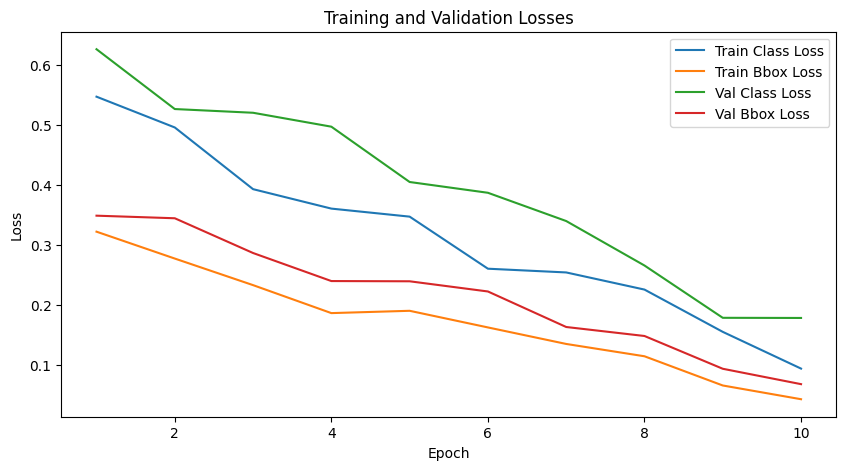

In [ ]:
# ADD YOUR CODE HERE

train_losses, val_losses = train_model(...)
plot_losses(train_losses, val_losses)
# DO NOT TRY TO REPLICATE... this is an example

**Visualize the attention weigths in order to understand how your model learned (Failure to do this, will result in losing points).
For that, use the 'context' variable returned by the Attention class to overlay them on the image.**  

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


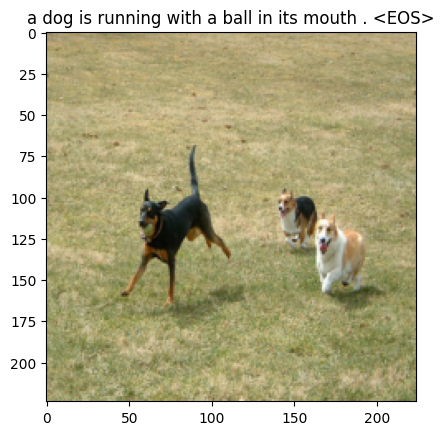

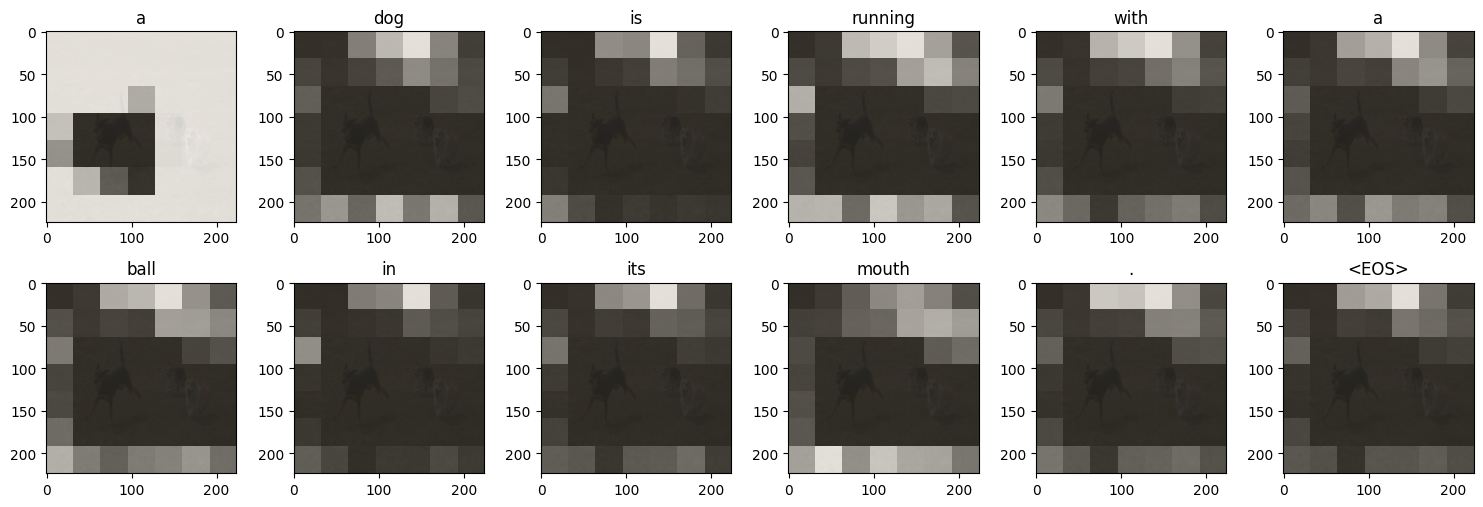

In [ ]:
# ADD YOUR CODE HERE

### 2.3. Evaluation on test set

Evaluate your trained model on the test set. Use the BLEU score as your metric: torchtext.data.metrics.bleu_score(...)

You may try BLEU-1,2 and 3.

In [ ]:
# ADD YOUR CODE HERE

### 2.4. Load an existing Image Captioning model
Feel free to choose any pre-trained image captioning model. For simplicity, try choosing a model already trained on Flickr8k.

In [254]:
from transformers import GPT2TokenizerFast, ViTImageProcessor, VisionEncoderDecoderModel
from torch.utils.data import Dataset
from torchtext.data import get_tokenizer
import requests
import torch
import numpy as np
from PIL import Image

import matplotlib.pyplot as plt
import os
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

In [255]:
model_raw = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning")

config.json:   0%|          | 0.00/4.61k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

In [256]:
image_processor = ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
tokenizer       = GPT2TokenizerFast.from_pretrained("nlpconnect/vit-gpt2-image-captioning")

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

### 2.5 Evaluate the chosen pre-trained captioning model on the test set
Use the same metrics chosen on step 2.3.

In [261]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

def show_n_generate(image, greedy=True, model=model_raw):
    if isinstance(image, str):
        image = Image.open(image)

    pixel_values = image_processor(image, return_tensors="pt").pixel_values
    plt.imshow(np.asarray(image))
    plt.show()

    if greedy:
        generated_ids = model.generate(pixel_values, max_new_tokens=30, attention_mask=pixel_values.new_ones(pixel_values.shape[:2]))
    else:
        generated_ids = model.generate(
            pixel_values,
            do_sample=True,
            max_new_tokens=30,
            top_k=5,
            attention_mask=pixel_values.new_ones(pixel_values.shape[:2])
        )

    generated_text = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    print(generated_text)

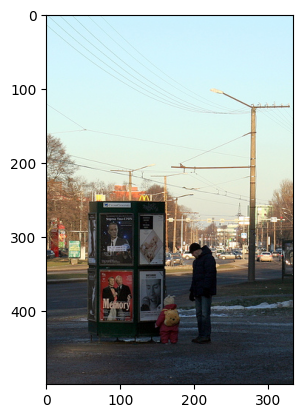

a man standing next to a food truck 


In [262]:
im = os.listdir("Images")[0]
show_n_generate(f"Images/{im}")

# 3. COMPARISON
Compare the performance of the two models. Show some visualizations of predictions from both models. Justify their differences. How would you improve your own custom model?

In [ ]:
# ADD YOUR CODE HERE